# Transfer Visualizations

t-SNE visualizations of transfer experiments.

In [1]:
import pickle
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

## Load Data

In [4]:
agent_map_f = [
    "F only",
    "F (BCSP)",
    "I only",
    "I (BCSP)",
    "F → I"
]

agent_map_i = [
    "F only",
    "F (BCSP)",
    "I only",
    "I (BCSP)",
    "F → I"
]

with open("../trajs/gen9vgc2024regf_enc.pkl",'rb') as f:
    df_f: pd.DataFrame = pickle.load(f)
with open("../trajs/gen9vgc2025regi_enc.pkl",'rb') as f:
    df_i: pd.DataFrame = pickle.load(f)

# normalize depth
df_f["progress"] = df_f.groupby("battle_id")["depth"].transform(lambda x: x / x.max())
df_i["progress"] = df_i.groupby("battle_id")["depth"].transform(lambda x: x / x.max())

## Numerical Analysis

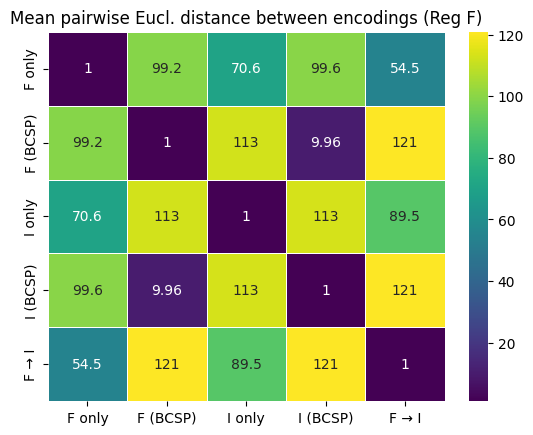

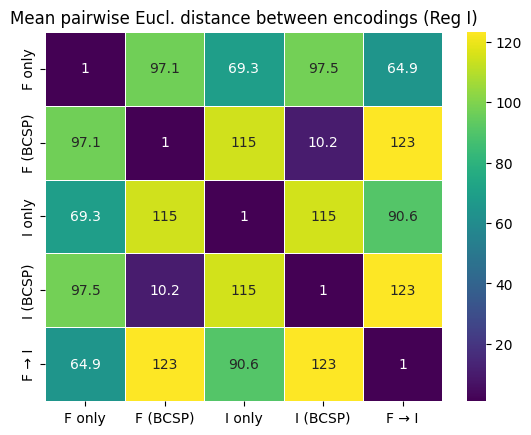

In [5]:
# mean pairwise distance between encodings
def mean_dist_enc(df, labels, reg):
    distance_matrix = np.identity(len(labels))
    for i in range(len(labels)):
        for j in range(i):
            distance_matrix[i][j] = (df[f"encoding_{i}"] - df[f"encoding_{j}"]).map(np.linalg.norm).mean()
    distance_matrix = distance_matrix + distance_matrix.T - np.identity(len(labels))

    sns.heatmap(
        distance_matrix,
        annot=True,
        fmt=".3g",
        cmap="viridis",
        linewidth=0.5,
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f"Mean pairwise Eucl. distance between encodings (Reg {reg})")
    plt.show()

mean_dist_enc(df_f, agent_map_f, "F")
mean_dist_enc(df_i, agent_map_i, "I")

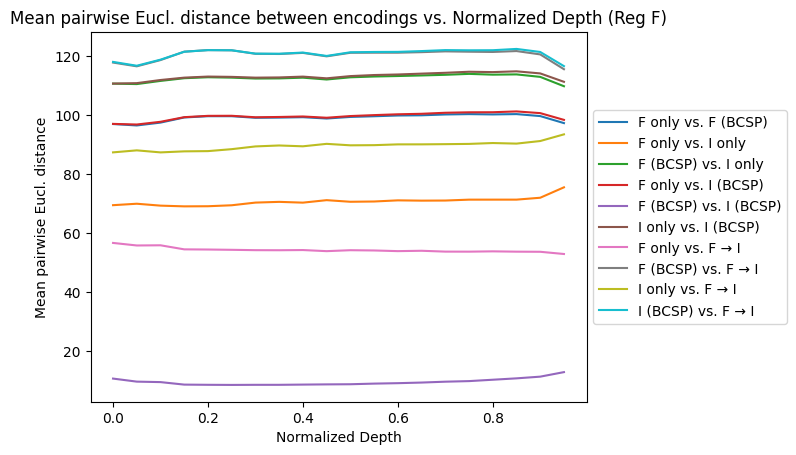

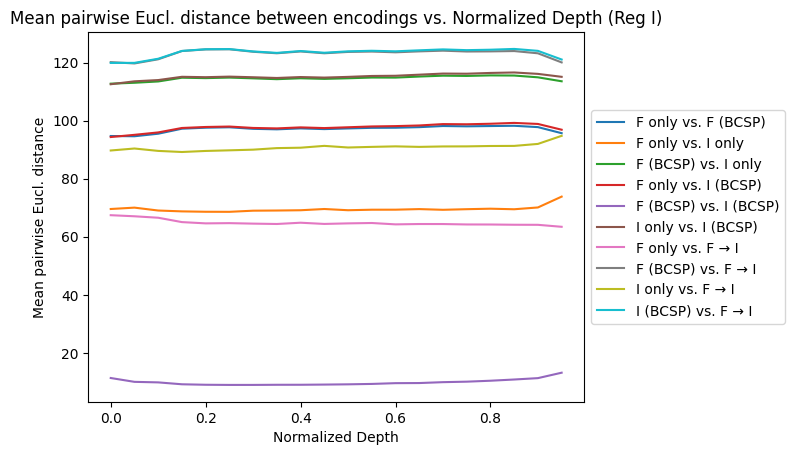

In [6]:
def mean_dist_enc_depth(df: pd.DataFrame, labels, reg):    
    depths = np.linspace(0, 1, num=20, endpoint=False)
    for i in range(len(labels)):
        for j in range(i):
            plt.plot(
                depths,
                [(
                    df[(d <= df["progress"]) & (df["progress"] < d+0.05)][f"encoding_{i}"] - \
                    df[(d <= df["progress"]) & (df["progress"] < d+0.05)][f"encoding_{j}"]
                ).map(np.linalg.norm).mean() for d in depths],
                label=f"{labels[j]} vs. {labels[i]}"
            )
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel("Normalized Depth")
    plt.ylabel("Mean pairwise Eucl. distance")
    plt.title(f"Mean pairwise Eucl. distance between encodings vs. Normalized Depth (Reg {reg})")
    plt.show()

mean_dist_enc_depth(df_f, agent_map_f, "F")
mean_dist_enc_depth(df_i, agent_map_i, "I")

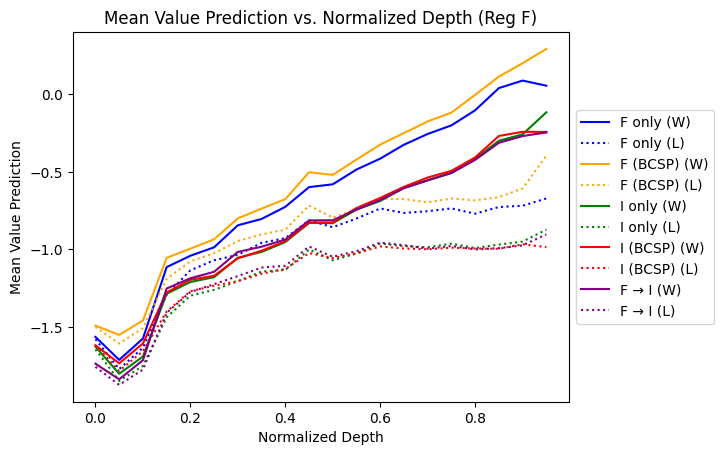

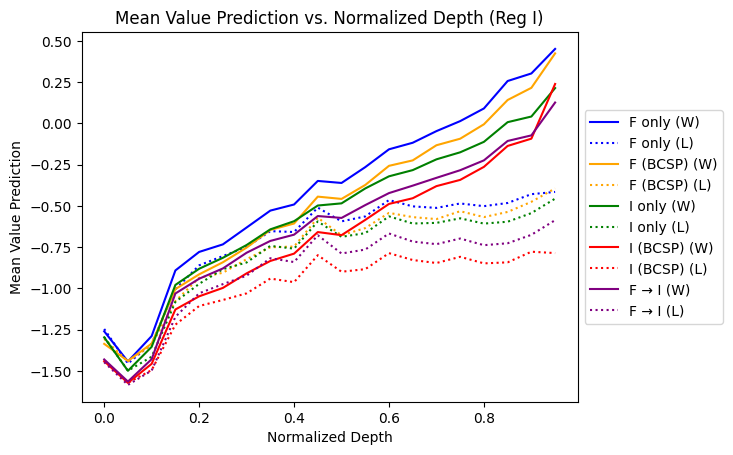

In [7]:
cmaps = [
    "Blue",
    "Orange",
    "Green",
    "Red",
    "Purple"
]

def mean_val_depth(df: pd.DataFrame, labels, reg):
    depths = np.linspace(0, 1, num=20, endpoint=False)
    for i in range(len(labels)):
        plt.plot(
            depths,
            [df[(df["winner"] == True) & (d <= df["progress"]) & (df["progress"] < d+0.05)][f"value_{i}"].mean() for d in depths],
            label=labels[i]+" (W)",
            color=cmaps[i]
        )
        plt.plot(
            depths,
            [df[(df["winner"] == False) & (d <= df["progress"]) & (df["progress"] < d+0.05)][f"value_{i}"].mean() for d in depths],
            label=labels[i]+" (L)",
            color=cmaps[i],
            linestyle=':'
        )
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel("Normalized Depth")
    plt.ylabel("Mean Value Prediction")
    plt.title(f"Mean Value Prediction vs. Normalized Depth (Reg {reg})")
    plt.show()

mean_val_depth(df_f, agent_map_f, "F")
mean_val_depth(df_i, agent_map_i, "I")

In [8]:
for i in range(len(agent_map_f)):
    eigvals = np.linalg.eigvalsh(np.cov(np.vstack(df_f[f"encoding_{i}"]).T)) # type: ignore
    pr = eigvals.sum()**2 / np.square(eigvals).sum()
    print(f"Participation Ratio for {agent_map_f[i]}: {pr}")

print()
for i in range(len(agent_map_i)):
    eigvals = np.linalg.eigvalsh(np.cov(np.vstack(df_i[f"encoding_{i}"]).T)) # type: ignore
    pr = eigvals.sum()**2 / np.square(eigvals).sum()
    print(f"Participation Ratio for {agent_map_i[i]}: {pr}")
# significantly lower PR for the transferred agent -> representation collapse

Participation Ratio for F only: 8.119483064697068
Participation Ratio for F (BCSP): 16.89629687546181
Participation Ratio for I only: 7.802679568552691
Participation Ratio for I (BCSP): 15.050886371650344
Participation Ratio for F → I: 6.430696152104037

Participation Ratio for F only: 9.674947983368162
Participation Ratio for F (BCSP): 16.89729850221841
Participation Ratio for I only: 7.530213461885533
Participation Ratio for I (BCSP): 16.715482044210894
Participation Ratio for F → I: 7.234996510308463


## t-SNE

In [35]:
RANDOM_STATE = 42
N_SAMPLES = 2_500

def tnse_encode(df: pd.DataFrame) -> tuple[pd.DataFrame | pd.Series, np.ndarray]:
    # random sample
    samples = df.sample(n=N_SAMPLES, random_state=RANDOM_STATE).stack()
    X = np.stack(samples.loc[pd.IndexSlice[:, [c for c in samples.index.unique(1) if c.startswith("encoding")]]].values) #type: ignore

    # PCA preprocessing
    pca = PCA(n_components=50, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=RANDOM_STATE,
        verbose=1
    )
    return samples, tsne.fit_transform(X_pca)

def filter_columns(df: pd.DataFrame, agents: list[int]) -> pd.DataFrame:
    mask = ["progress", "winner"] # included by default
    for i in agents:
        mask.append(f"encoding_{i}")
        mask.append(f"value_{i}")
    return df[mask]

df_sample_f, tsne_f = tnse_encode(filter_columns(df_f, [0, 1, 2]))
df_sample_i, tsne_i = tnse_encode(filter_columns(df_i, [0, 1, 2]))

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 7500 samples in 0.000s...
[t-SNE] Computed neighbors for 7500 samples in 0.117s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7500
[t-SNE] Computed conditional probabilities for sample 2000 / 7500
[t-SNE] Computed conditional probabilities for sample 3000 / 7500
[t-SNE] Computed conditional probabilities for sample 4000 / 7500
[t-SNE] Computed conditional probabilities for sample 5000 / 7500
[t-SNE] Computed conditional probabilities for sample 6000 / 7500
[t-SNE] Computed conditional probabilities for sample 7000 / 7500
[t-SNE] Computed conditional probabilities for sample 7500 / 7500
[t-SNE] Mean sigma: 14.156286
[t-SNE] KL divergence after 250 iterations with early exaggeration: 83.461411
[t-SNE] KL divergence after 1000 iterations: 1.843335
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 7500 samples in 0.000s...
[t-SNE] Computed neighbors for 7500 samples in 0.117s...
[t-SNE] Computed conditional

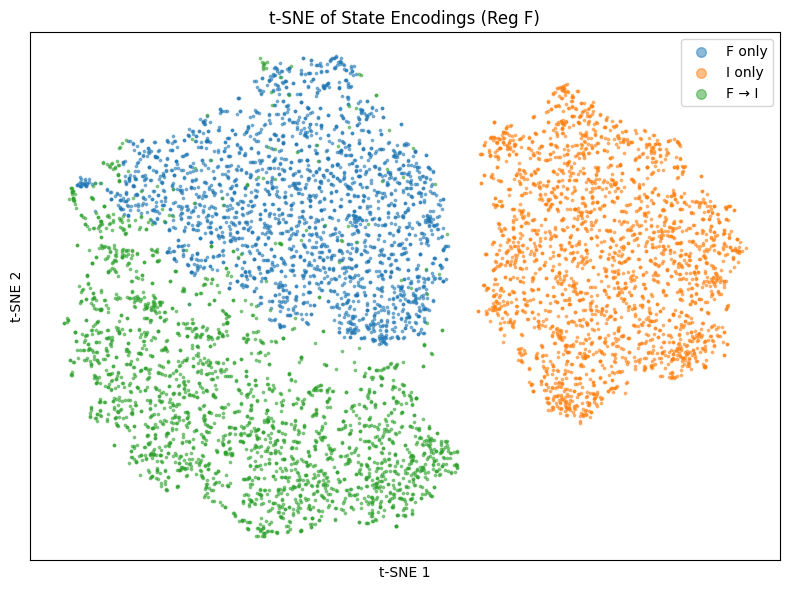

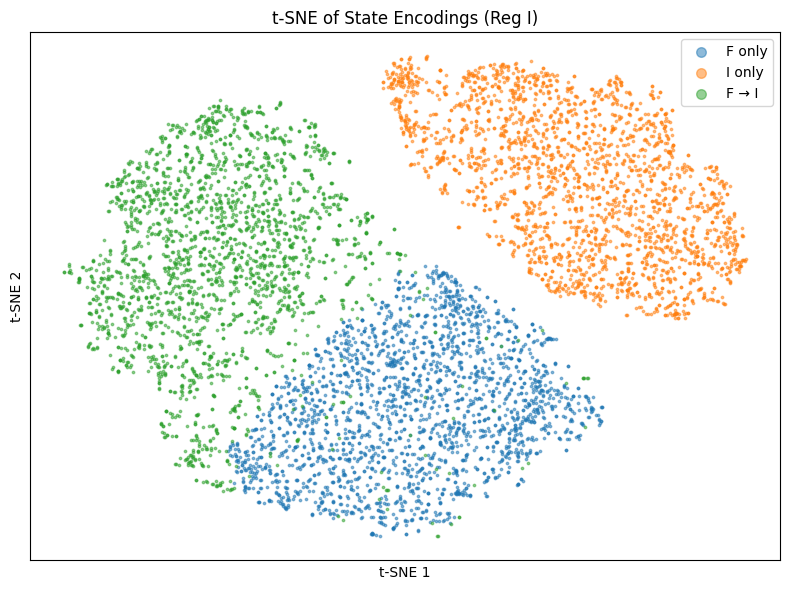

In [36]:
def plot_tnse(samples: pd.DataFrame | pd.Series, X_tsne: np.ndarray, agent_map: list[str], reg: str):
    plt.figure(figsize=(8, 6))

    columns = [c for c in samples.index.unique(1) if c.startswith("encoding")]
    for c in columns:
        mask = samples.loc[pd.IndexSlice[:, columns]].reset_index()["level_1"] == c
        plt.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            s=3,
            alpha=0.5,
            label=agent_map[int(c[-1])]
        )

    plt.xlabel("t-SNE 1")
    plt.xticks([])
    plt.ylabel("t-SNE 2")
    plt.yticks([])
    plt.title(f"t-SNE of State Encodings (Reg {reg})")
    plt.legend(markerscale=4)
    plt.tight_layout()
    plt.show()

plot_tnse(df_sample_f, tsne_f, agent_map_f, "F")
plot_tnse(df_sample_i, tsne_i, agent_map_i, "I")

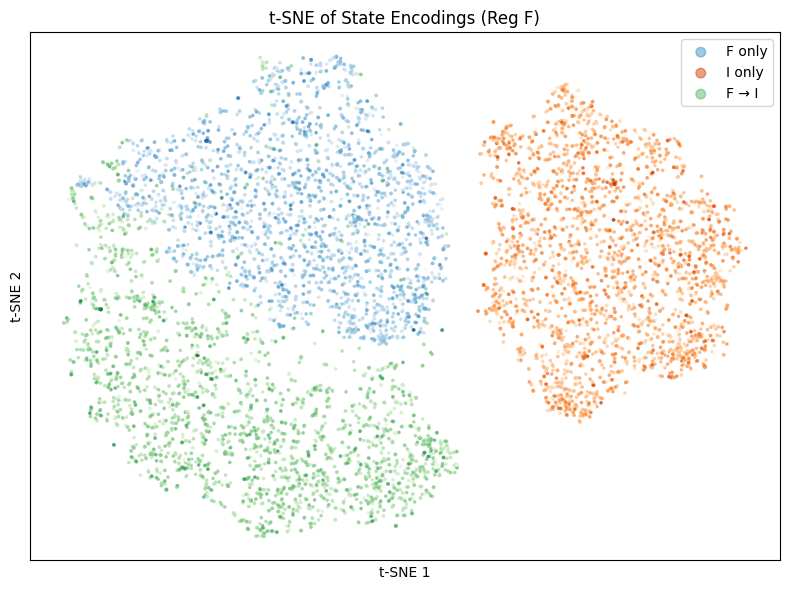

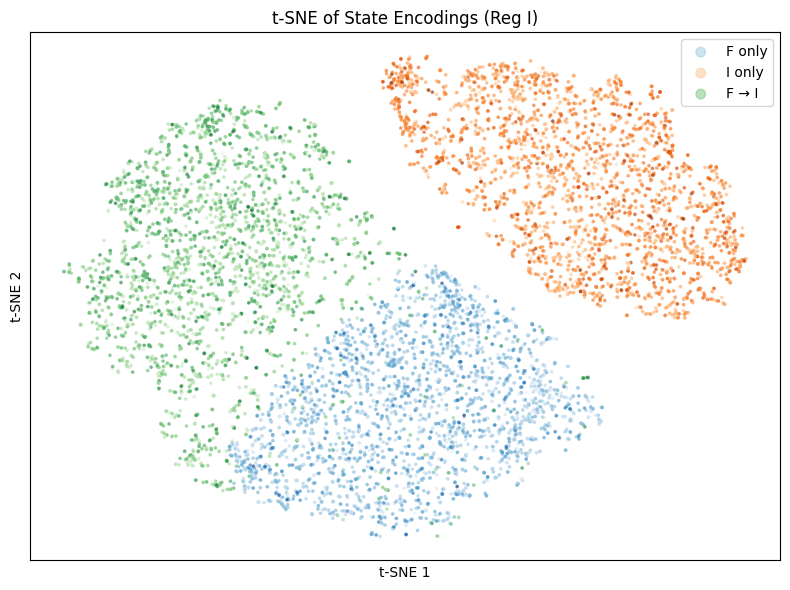

In [40]:
cmaps = [
    "Blues",
    "Oranges",
    "Greens"
]

def plot_tnse_grad(samples: pd.DataFrame | pd.Series, X_tsne: np.ndarray, agent_map: list[str], reg: str):
    plt.figure(figsize=(8, 6))

    columns = [c for c in samples.index.unique(1) if c.startswith("encoding")]
    depth = samples.xs("progress", level=1).repeat(len(columns)).values # type: ignore
    values = samples.loc[pd.IndexSlice[:, [c for c in samples.index.unique(1) if c.startswith("value")]]].values

    for c in columns:
        mask = samples.loc[pd.IndexSlice[:, columns]].reset_index()["level_1"] == c
        plt.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            c=values[mask],
            cmap=cmaps[int(c[-1])],
            s=3,
            alpha=0.5,
            label=agent_map[int(c[-1])]
        )

    plt.xlabel("t-SNE 1")
    plt.xticks([])
    plt.ylabel("t-SNE 2")
    plt.yticks([])
    plt.title(f"t-SNE of State Encodings (Reg {reg})")
    plt.legend(markerscale=4)
    plt.tight_layout()
    plt.show()

plot_tnse_grad(df_sample_f, tsne_f, agent_map_f, "F")
plot_tnse_grad(df_sample_i, tsne_i, agent_map_i, "I")

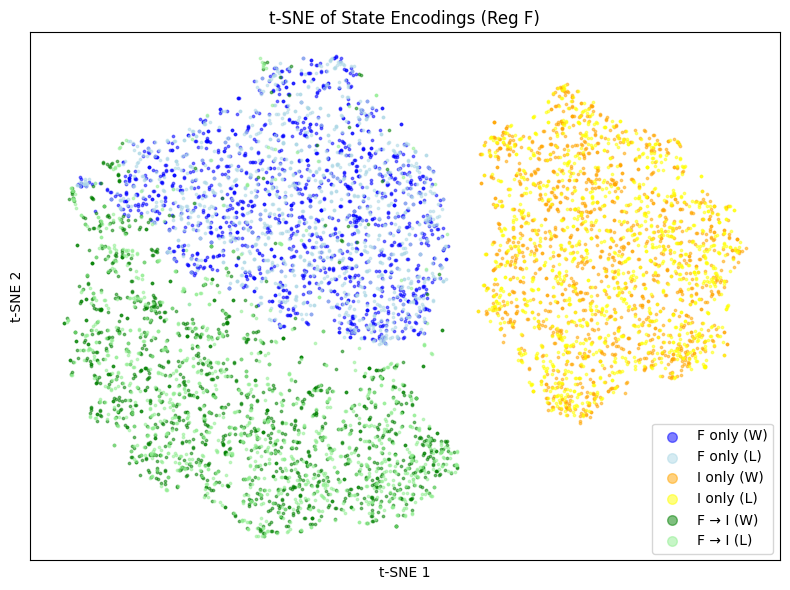

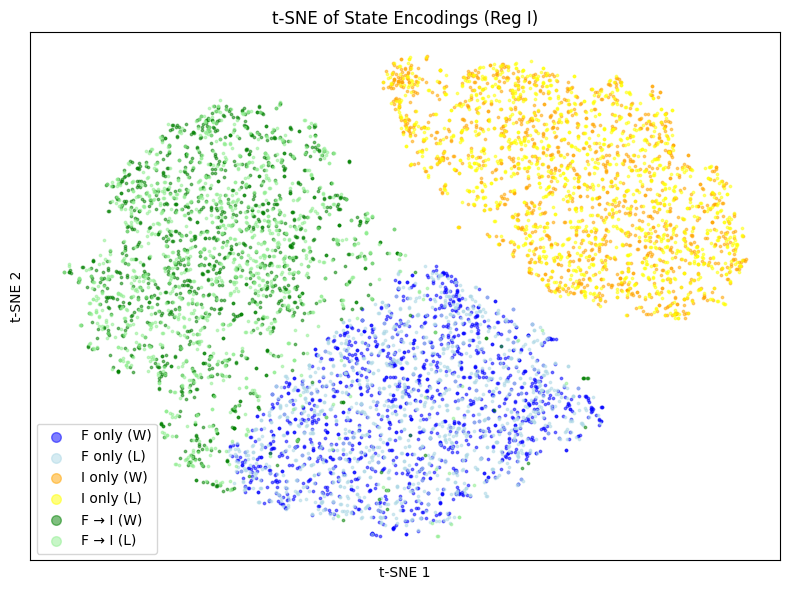

In [42]:
colors = [
    "lightblue",
    "blue",
    "yellow",
    "orange",
    "lightgreen",
    "green"
]

def plot_tnse_win(samples: pd.DataFrame | pd.Series, X_tsne: np.ndarray, agent_map: list[str], reg: str):
    plt.figure(figsize=(8, 6))

    columns = [c for c in samples.index.unique(1) if c.startswith("encoding")]
    winner = samples.xs("winner", level=1).repeat(len(columns)).values # type: ignore

    for c in columns:
        mask1 = samples.loc[pd.IndexSlice[:, columns]].reset_index()["level_1"] == c
        plt.scatter(
            X_tsne[mask1 & winner, 0],
            X_tsne[mask1 & winner, 1],
            c=colors[int(c[-1])*2+1],
            s=3,
            alpha=0.5,
            label=agent_map[int(c[-1])]+" (W)"
        )
        plt.scatter(
            X_tsne[mask1 & np.logical_not(winner), 0],
            X_tsne[mask1 & np.logical_not(winner), 1],
            c=colors[int(c[-1])*2],
            s=3,
            alpha=0.5,
            label=agent_map[int(c[-1])]+" (L)"
        )

    plt.xlabel("t-SNE 1")
    plt.xticks([])
    plt.ylabel("t-SNE 2")
    plt.yticks([])
    plt.title(f"t-SNE of State Encodings (Reg {reg})")
    plt.legend(markerscale=4)
    plt.tight_layout()
    plt.show()

plot_tnse_win(df_sample_f, tsne_f, agent_map_f, "F")
plot_tnse_win(df_sample_i, tsne_i, agent_map_i, "I")

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2500 samples in 0.000s...
[t-SNE] Computed neighbors for 2500 samples in 0.056s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2500
[t-SNE] Computed conditional probabilities for sample 2000 / 2500
[t-SNE] Computed conditional probabilities for sample 2500 / 2500
[t-SNE] Mean sigma: 13.391480
[t-SNE] KL divergence after 250 iterations with early exaggeration: 79.291809
[t-SNE] KL divergence after 1000 iterations: 1.669860
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2500 samples in 0.000s...
[t-SNE] Computed neighbors for 2500 samples in 0.045s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2500
[t-SNE] Computed conditional probabilities for sample 2000 / 2500
[t-SNE] Computed conditional probabilities for sample 2500 / 2500
[t-SNE] Mean sigma: 13.948521
[t-SNE] KL divergence after 250 iterations with early exaggeration: 79.024445
[t-SNE] KL divergence after 1000 iterations: 1.67164

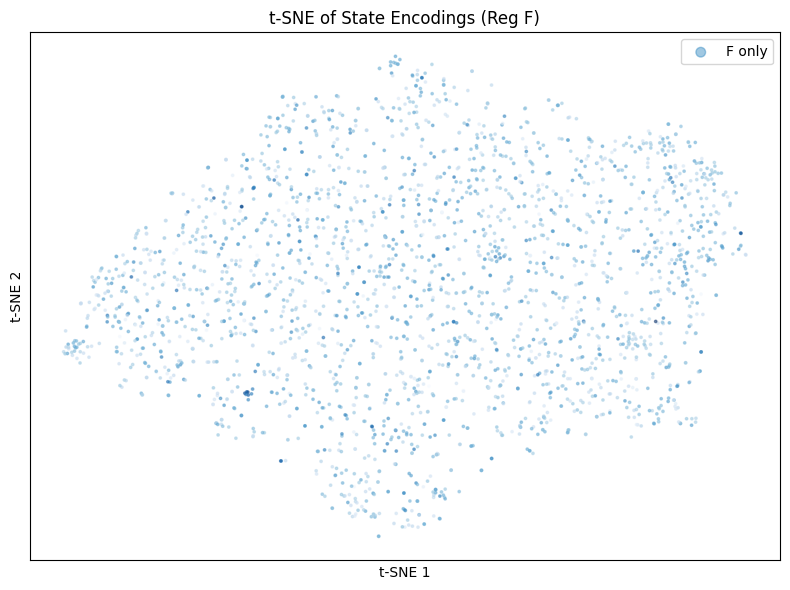

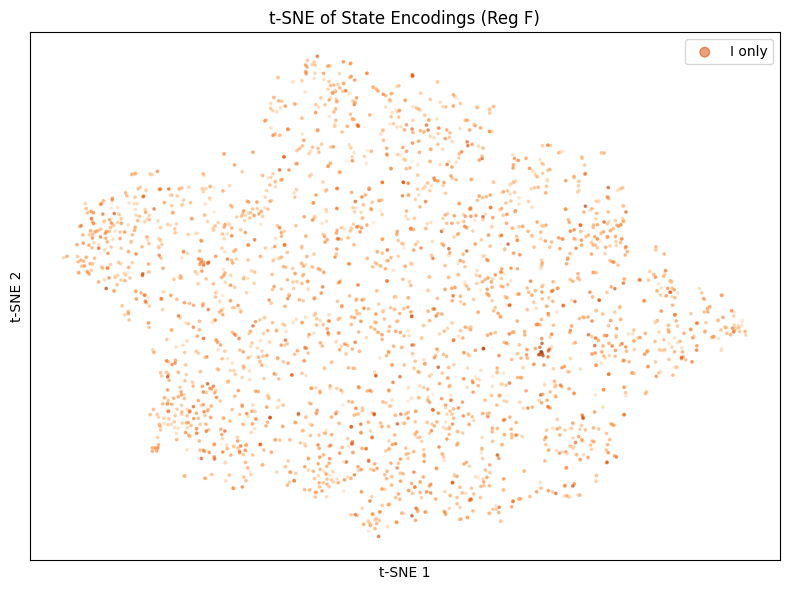

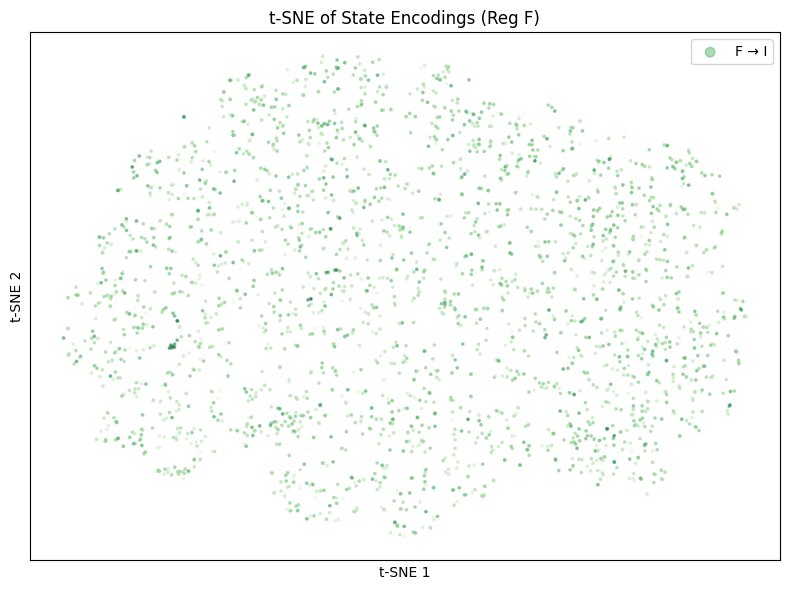

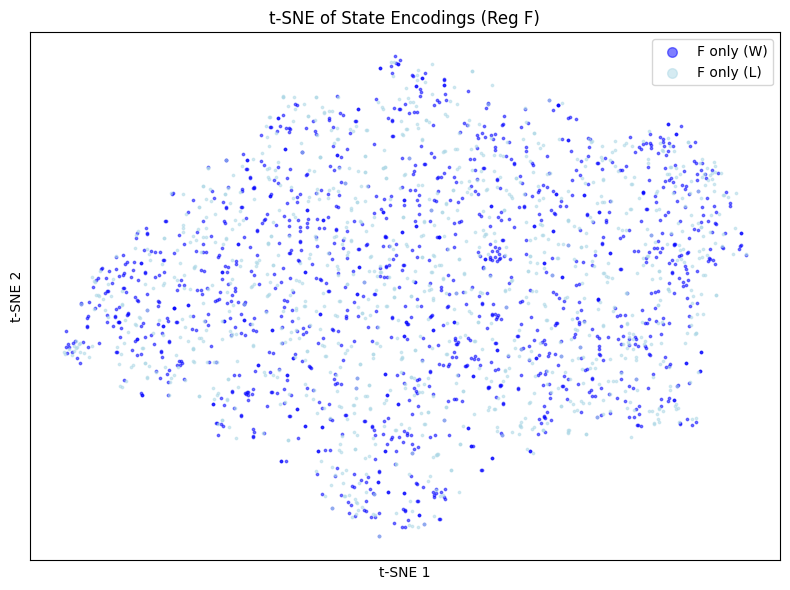

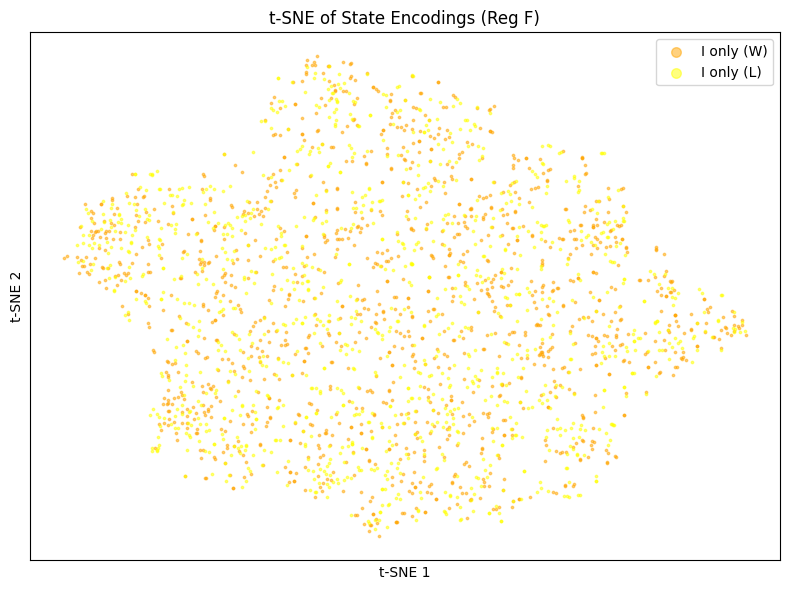

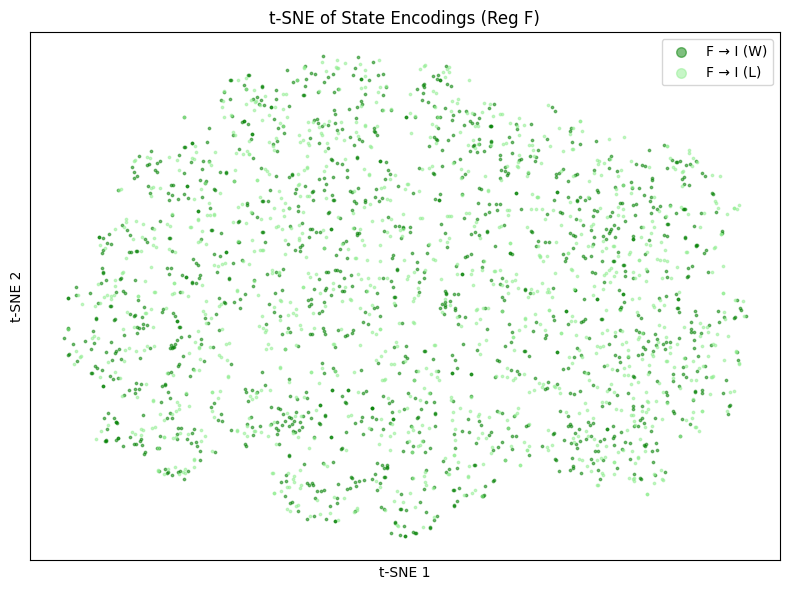

In [43]:
df_sample_f_only, tsne_f_only = tnse_encode(filter_columns(df_f, [0]))
df_sample_i_only, tsne_i_only = tnse_encode(filter_columns(df_f, [1]))
df_sample_f_to_i, tsne_f_to_i = tnse_encode(filter_columns(df_f, [2]))

plot_tnse_grad(df_sample_f_only, tsne_f_only, agent_map_f, "F")
plot_tnse_grad(df_sample_i_only, tsne_i_only, agent_map_f, "F")
plot_tnse_grad(df_sample_f_to_i, tsne_f_to_i, agent_map_f, "F")

plot_tnse_win(df_sample_f_only, tsne_f_only, agent_map_f, "F")
plot_tnse_win(df_sample_i_only, tsne_i_only, agent_map_f, "F")
plot_tnse_win(df_sample_f_to_i, tsne_f_to_i, agent_map_f, "F")

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2500 samples in 0.001s...
[t-SNE] Computed neighbors for 2500 samples in 0.061s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2500
[t-SNE] Computed conditional probabilities for sample 2000 / 2500
[t-SNE] Computed conditional probabilities for sample 2500 / 2500
[t-SNE] Mean sigma: 12.361722
[t-SNE] KL divergence after 250 iterations with early exaggeration: 79.778114
[t-SNE] KL divergence after 1000 iterations: 1.768860
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2500 samples in 0.000s...
[t-SNE] Computed neighbors for 2500 samples in 0.046s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2500
[t-SNE] Computed conditional probabilities for sample 2000 / 2500
[t-SNE] Computed conditional probabilities for sample 2500 / 2500
[t-SNE] Mean sigma: 15.700304
[t-SNE] KL divergence after 250 iterations with early exaggeration: 79.269920
[t-SNE] KL divergence after 1000 iterations: 1.75818

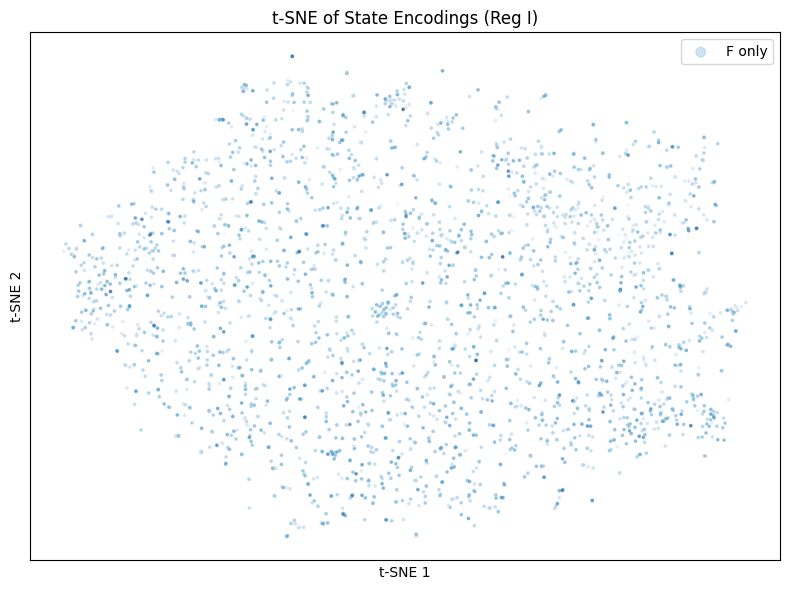

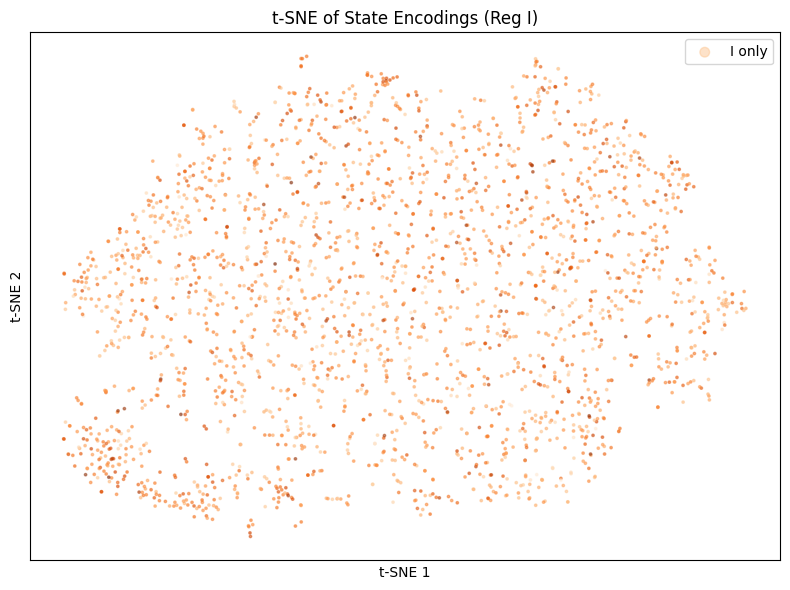

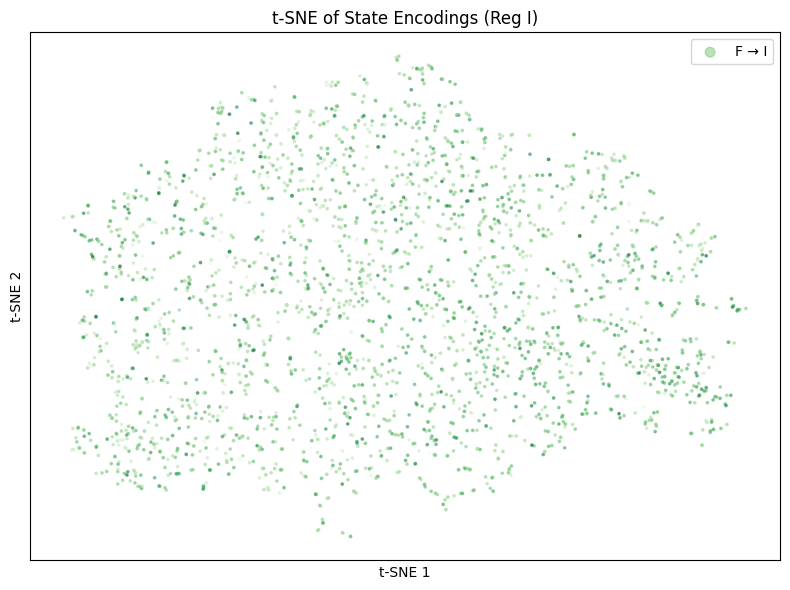

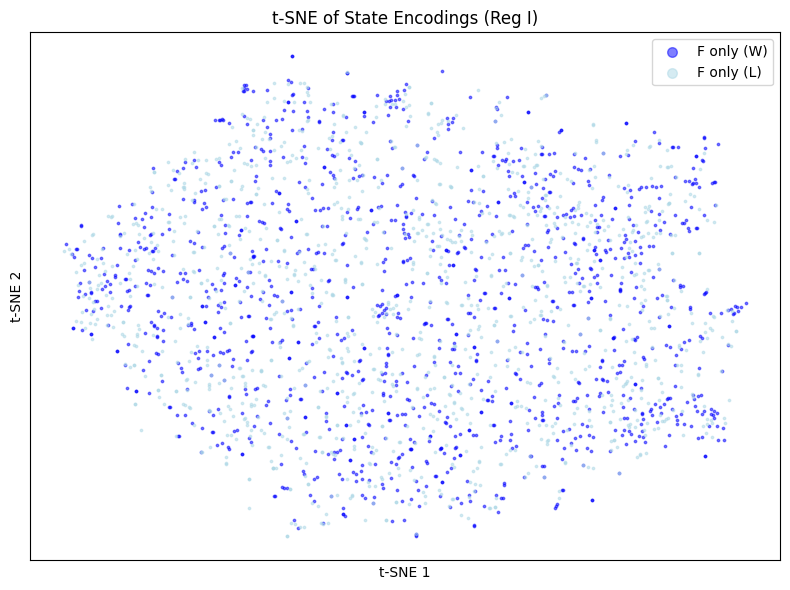

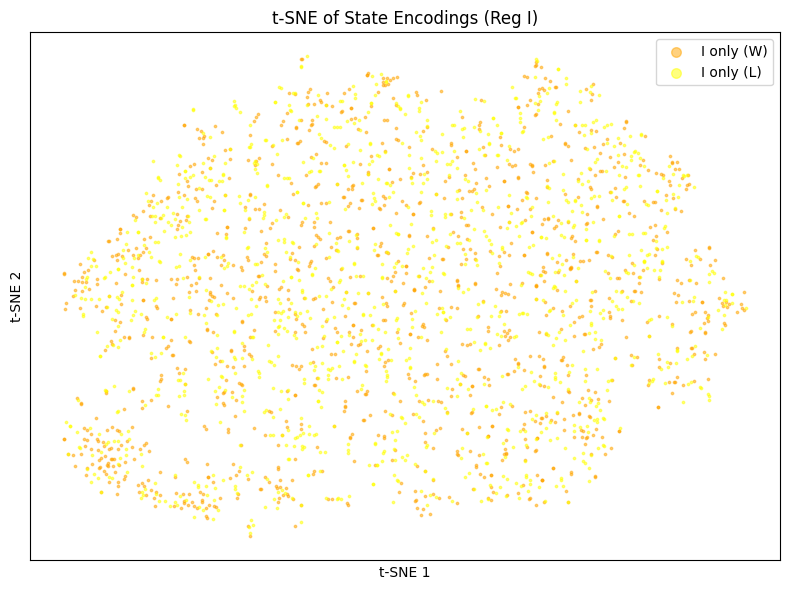

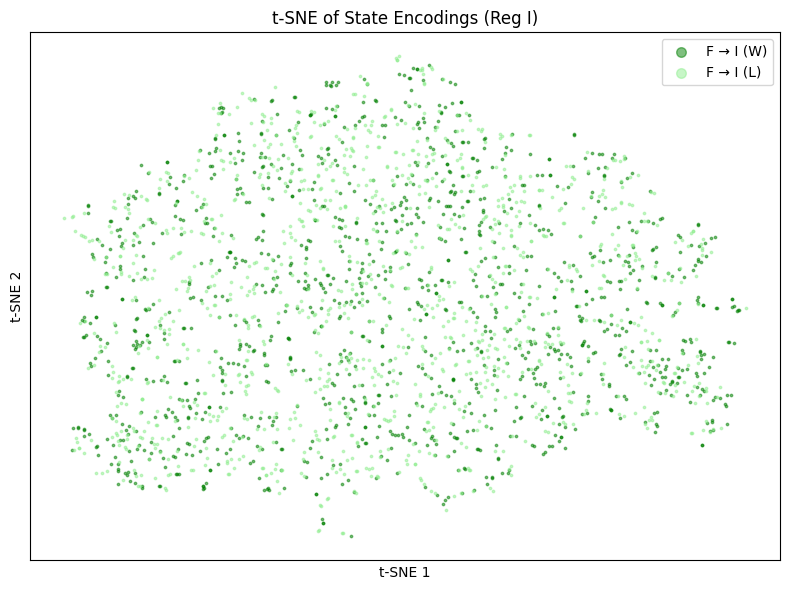

In [44]:
df_sample_f_only, tsne_f_only = tnse_encode(filter_columns(df_i, [0]))
df_sample_i_only, tsne_i_only = tnse_encode(filter_columns(df_i, [1]))
df_sample_f_to_i, tsne_f_to_i = tnse_encode(filter_columns(df_i, [2]))

plot_tnse_grad(df_sample_f_only, tsne_f_only, agent_map_f, "I")
plot_tnse_grad(df_sample_i_only, tsne_i_only, agent_map_f, "I")
plot_tnse_grad(df_sample_f_to_i, tsne_f_to_i, agent_map_f, "I")

plot_tnse_win(df_sample_f_only, tsne_f_only, agent_map_f, "I")
plot_tnse_win(df_sample_i_only, tsne_i_only, agent_map_f, "I")
plot_tnse_win(df_sample_f_to_i, tsne_f_to_i, agent_map_f, "I")